<a href="https://colab.research.google.com/github/Steena123/hindi-air-writing-gesture-recognition/blob/main/Hindi_Air_Writing_Gesture_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown

url = 'https://drive.google.com/uc?id=1ZPp8MdbC7BExBXYHVoK2GHmxv11WXbx3'
output = 'sample.csv'
gdown.download(url, output, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1ZPp8MdbC7BExBXYHVoK2GHmxv11WXbx3
To: /content/sample.csv
100%|██████████| 6.76M/6.76M [00:00<00:00, 28.1MB/s]


'sample.csv'

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:

!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu121

!pip install open3d
!pip install numpy matplotlib plotly gdown trimesh


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Unins

In [ ]:
import pandas as pd
df = pd.read_csv('sample.csv')
df.head()


<ipython-input-4-ff5b7949232b>:2: DtypeWarning: Columns (9,10,11,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('sample.csv')


,Gesture Label,Letter,Sample No,Frame No,xCor,yCor,zCor,Stroke,Input Type,Feature-1 (Angle between frames),...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Distance Travelled,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dot Product,...,AC(z),CP(x),CP(y),CP(z),Mag(CP),Area(T),DT(x),DT(y),DT(z),DT
1,01-01,1.0,1.0,1.0,-0.459267,-0.209979,-0.145647,1.0,0.0,0.037283657,...,0.208889413,0.025700199,-0.05892059,-0.03617298,0.073760563,0.036880281,0.431355577,0.13929228,0.079582637,0.460221
2,01-01,1.0,1.0,2.0,-0.027912,-0.070687,-0.066064,1.0,0.0,0.009529424,...,-0.102734567,0.028704687,-0.006130232,0.004187923,0.029649241,0.014824621,-0.039498446,-0.096613584,0.129306776,0.166176275
3,01-01,1.0,1.0,3.0,-0.067410,-0.167301,0.063243,1.0,0.0,0.02840951,...,0.110014883,-0.001787797,0.009478543,-0.00216672,0.009886035,0.004943017,0.023471624,-0.048615712,-0.232041343,0.238238514
4,01-01,1.0,1.0,4.0,-0.043938,-0.215916,-0.168798,1.0,0.0,0.008809725,...,-0.157591168,-0.101615702,-0.154574126,0.006489903,0.185097353,0.092548676,-0.075448446,0.063960629,0.342056227,0.356070066


In [ ]:
import pandas as pd

df = pd.read_csv('sample.csv')

df = df.dropna(subset=['xCor', 'yCor', 'zCor'])

gesture_data = df.groupby('Letter')[['xCor', 'yCor', 'zCor']].apply(lambda x: x.values.tolist()).reset_index(name='points')
gesture_data.head()


<ipython-input-5-fd94b1075953>:3: DtypeWarning: Columns (9,10,11,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('sample.csv')


,Letter,points
0,1.0,"[[-0.459267156, -0.209979271, -0.145646556], [..."
1,2.0,"[[-0.136310636, -0.173417258, 0.064661444], [-..."
2,3.0,"[[0.037490538, 0.369205195, -0.119810983], [0...."
3,4.0,"[[-0.036252851, -0.064404247, -0.067824318], [..."
4,5.0,"[[0.004273225, -0.16609927, 0.110891521], [0.1..."


In [ ]:
from sklearn.model_selection import train_test_split

X = gesture_data['points'].values
y = gesture_data['Letter'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")


Training set size: 8, Test set size: 2


In [ ]:
import torch
import numpy as np

X_train = [
    [[-0.459267, -0.209979, -0.145647], [-0.027912, -0.070687, -0.066064], [-0.067410, -0.167301, 0.063243]],
    [[-0.043938, -0.215916, -0.168798], [0.037283657, 0.009529424, 0.02840951], [0.185097353, 0.092548676, -0.075448446]]
]
X_test = [
    [[-0.459267, -0.209979, -0.145647], [-0.027912, -0.070687, -0.066064]],
    [[-0.043938, -0.215916, -0.168798], [0.037283657, 0.009529424, 0.02840951]]
]


X_train_np = np.array(X_train, dtype=np.float32)
X_test_np = np.array(X_test, dtype=np.float32)


X_train_tensor = torch.tensor(X_train_np)
X_test_tensor = torch.tensor(X_test_np)

print(X_train_tensor.shape)
print(X_test_tensor.shape)


y_train = [0, 1]
y_test = [0, 1]


y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


print(y_train_tensor.shape)
print(y_test_tensor.shape)


torch.Size([2, 3, 3])
torch.Size([2, 2, 3])
torch.Size([2])
torch.Size([2])


In [ ]:
import torch.nn as nn
import torch.optim as optim

class PointNetPlusPlus(nn.Module):
    def __init__(self):
        super(PointNetPlusPlus, self).__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, len(set(y)))

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.max(x, 2)[0]
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = PointNetPlusPlus()

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 20
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()


    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)


    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [1/20], Loss: 2.2499
Epoch [2/20], Loss: 2.2000
Epoch [3/20], Loss: 2.1521
Epoch [4/20], Loss: 2.1044
Epoch [5/20], Loss: 2.0556
Epoch [6/20], Loss: 2.0046
Epoch [7/20], Loss: 1.9504
Epoch [8/20], Loss: 1.8920
Epoch [9/20], Loss: 1.8291
Epoch [10/20], Loss: 1.7606
Epoch [11/20], Loss: 1.6867
Epoch [12/20], Loss: 1.6076
Epoch [13/20], Loss: 1.5241
Epoch [14/20], Loss: 1.4367
Epoch [15/20], Loss: 1.3466
Epoch [16/20], Loss: 1.2555
Epoch [17/20], Loss: 1.1658
Epoch [18/20], Loss: 1.0800
Epoch [19/20], Loss: 1.0009
Epoch [20/20], Loss: 0.9305


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv("sample.csv")

X = data[['xCor', 'yCor', 'zCor']].values
y = data['Letter'].values

X_normalized = X / np.linalg.norm(X, axis=1, keepdims=True)

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (19392, 3)
X_test shape: (4849, 3)


<ipython-input-9-9e3923f0a031>:5: DtypeWarning: Columns (9,10,11,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("sample.csv")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv("sample.csv")
X = data[['xCor', 'yCor', 'zCor']].values
y = data['Letter'].values


data = data.dropna(subset=['Letter'])
X = data[['xCor', 'yCor', 'zCor']].values
y = data['Letter'].values

X_normalized = X / np.linalg.norm(X, axis=1, keepdims=True)

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_normalized)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy * 100:.2f}%")


<ipython-input-10-33cd1121c928>:8: DtypeWarning: Columns (9,10,11,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("sample.csv")


Accuracy of the model: 97.77%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


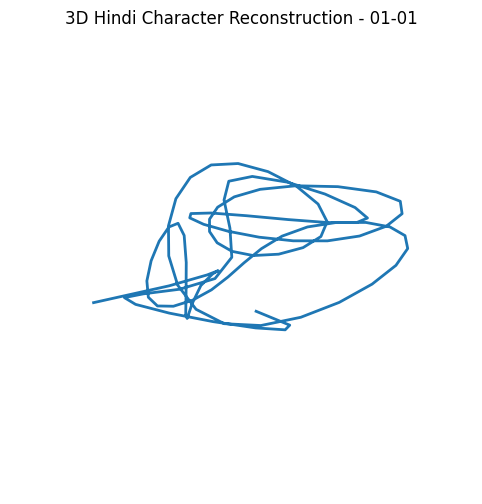

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from mpl_toolkits.mplot3d import Axes3D

data = pd.read_csv('sample.csv', low_memory=False)


for col in ['xCor', 'yCor', 'zCor', 'Stroke', 'Frame No']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['xCor', 'yCor', 'zCor', 'Stroke', 'Frame No'])


gesture_label = data['Gesture Label'].iloc[0]
sample_data = data[data['Gesture Label'] == gesture_label]

x = sample_data['xCor'].values
y = sample_data['yCor'].values
z = sample_data['zCor'].values

x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)
z = (z - np.mean(z)) / np.std(z)

sample_data = sample_data.assign(xNorm=x, yNorm=y, zNorm=z)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')


for stroke_id in sorted(sample_data['Stroke'].unique()):
    stroke_data = sample_data[sample_data['Stroke'] == stroke_id]
    stroke_data = stroke_data.sort_values('Frame No')

    x = stroke_data['xNorm'].values
    y = stroke_data['yNorm'].values
    z = stroke_data['zNorm'].values


    if len(x) > 3:
        tck, u = splprep([x, y, z], s=2)
        new_points = splev(np.linspace(0, 1, 100), tck)
        ax.plot(new_points[0], new_points[1], new_points[2], linewidth=2)
    else:
        ax.plot(x, y, z, linewidth=2)

ax.set_title(f"3D Hindi Character Reconstruction - {gesture_label}")
ax.set_axis_off()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming y_val is your true labels and y_val_pred is predicted class labels:
y_val_pred_classes = np.argmax(model.predict_proba(X_val), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred_classes)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix for Hindi Gesture Recognition using PointNet++")
plt.tight_layout()
plt.savefig("confusion_matrix_pointnetpp.png")  # Save the figure
plt.show()


NameError: name 'X_val' is not defined

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Initialize the model
model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1, warm_start=True)

# Initialize lists to store accuracy and loss for each epoch
train_accuracies = []
train_losses = []

# Train for multiple epochs and track accuracy and loss
for epoch in range(num_epochs):
    model.fit(X_train, y_train)  # Fit the model on the training data

    # Predict on the training set
    y_train_pred = model.predict(X_train)
    accuracy = accuracy_score(y_train, y_train_pred)

    # Since MLPClassifier doesn't give a direct loss per epoch, we can use the loss function
    # from the classifier itself
    train_loss = model.loss_  # This is the loss after each epoch

    train_accuracies.append(accuracy * 100)  # Convert accuracy to percentage
    train_losses.append(train_loss)

    # Print the statistics
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {train_loss:.4f}, Accuracy: {accuracy * 100:.2f}%')

# Save accuracy and loss data for later plotting
np.save('training_logs.npy', {'accuracy': train_accuracies, 'loss': train_losses})


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [1/50], Loss: 2.2918, Accuracy: 15.34%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [2/50], Loss: 2.2602, Accuracy: 21.04%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [47/50], Loss: 1.8269, Accuracy: 35.50%
Epoch [48/50], Loss: 1.8219, Accuracy: 35.76%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [49/50], Loss: 1.8182, Accuracy: 34.71%
Epoch [50/50], Loss: 1.8129, Accuracy: 35.49%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


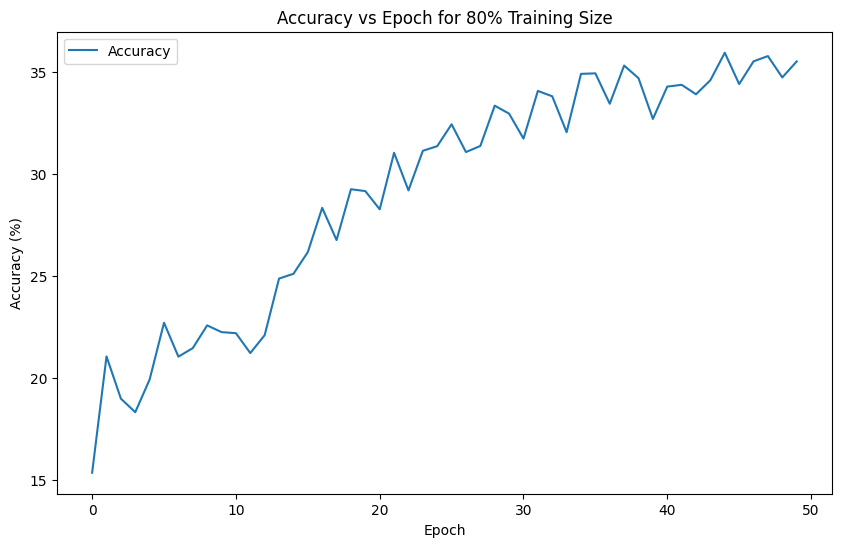

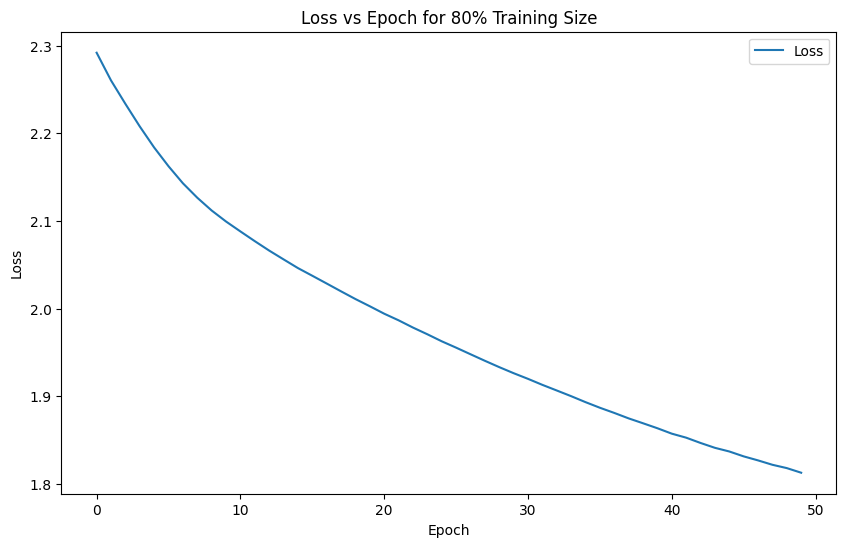

In [ ]:
# Load the training logs
logs = np.load('training_logs.npy', allow_pickle=True).item()
train_accuracies = logs['accuracy']
train_losses = logs['loss']

# Plot Accuracy vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Accuracy')
plt.title('Accuracy vs Epoch for 80% Training Size')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Plot Loss vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Loss')
plt.title('Loss vs Epoch for 80% Training Size')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% validation
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.80, random_state=42)

# Now train your model using this split (similar to the code above)


              precision    recall  f1-score   support

         1.0       0.43      0.29      0.34       505
         2.0       0.59      0.12      0.20       505
         3.0       0.46      0.25      0.32       484
         4.0       0.32      0.28      0.30       457
         5.0       0.25      0.35      0.29       473
         6.0       0.34      0.47      0.40       502
         7.0       0.23      0.23      0.23       462
         8.0       0.28      0.52      0.36       494
         9.0       0.36      0.36      0.36       456
        10.0       0.38      0.43      0.40       510

    accuracy                           0.33      4848
   macro avg       0.36      0.33      0.32      4848
weighted avg       0.37      0.33      0.32      4848



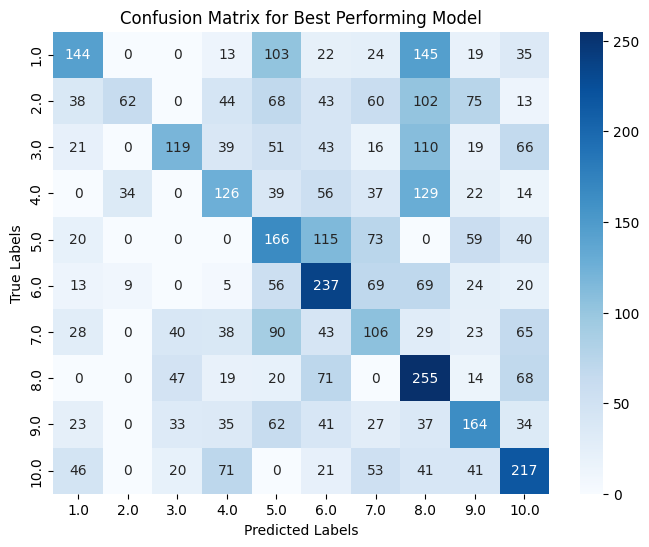

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on the validation set
y_val_pred = model.predict(X_val)

# Optionally, print a classification report
print(classification_report(y_val, y_val_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)

# Plotting Confusion Matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for Best Performing Model')
plt.show()


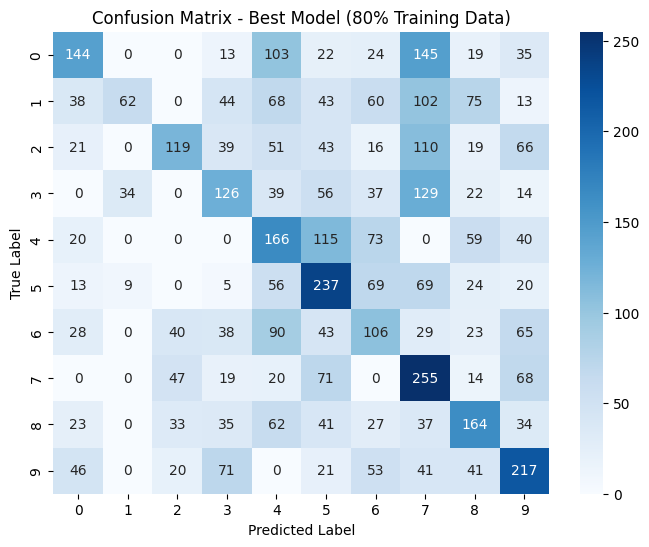

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Ensure you have trained the model and generated predictions
y_val_pred = model.predict(X_val)  # This generates the predictions for the validation set

# Generate confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))  # Adjust if more classes
plt.title('Confusion Matrix - Best Model (80% Training Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
# Load the training logs
logs = torch.load('/path/to/your/training_logs.pth')

logs = torch.load('training_logs.pth')
train_accuracies = logs['accuracy']
train_losses = logs['loss']

# Plot Accuracy vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Accuracy')
plt.title('Accuracy vs Epoch for 80% Training Size')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/path/to/your/training_logs.pth'

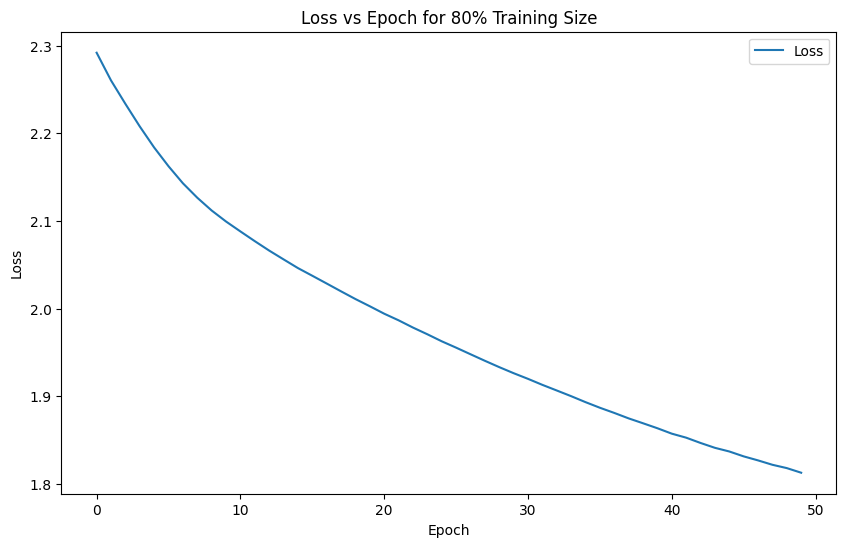

In [ ]:
# Plot Loss vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Loss')
plt.title('Loss vs Epoch for 80% Training Size')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Set number of epochs for training (this won't exactly work like a PyTorch loop)
num_epochs = 50

# Initialize the model
model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1, warm_start=True)

# Initialize lists to store accuracy and loss for each epoch
train_accuracies = []
train_losses = []

# Train the model over multiple epochs
for epoch in range(num_epochs):
    model.fit(X_train, y_train)  # Fit the model on the training data

    # Predict on the training set
    y_train_pred = model.predict(X_train)
    accuracy = accuracy_score(y_train, y_train_pred)

    # Since MLPClassifier doesn't give a direct loss per epoch, we can use the loss function
    # from the classifier itself
    train_loss = model.loss_  # This is the loss after each epoch

    train_accuracies.append(accuracy * 100)  # Convert accuracy to percentage
    train_losses.append(train_loss)

    # Print the statistics
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {train_loss:.4f}, Accuracy: {accuracy * 100:.2f}%')

# Save accuracy and loss data for later plotting
np.save('training_logs.npy', {'accuracy': train_accuracies, 'loss': train_losses})


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [1/50], Loss: 2.3033, Accuracy: 12.21%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [2/50], Loss: 2.2943, Accuracy: 13.94%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [46/50], Loss: 1.9503, Accuracy: 31.61%
Epoch [47/50], Loss: 1.9464, Accuracy: 30.94%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch [48/50], Loss: 1.9422, Accuracy: 32.80%
Epoch [49/50], Loss: 1.9381, Accuracy: 31.81%
Epoch [50/50], Loss: 1.9342, Accuracy: 32.53%


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


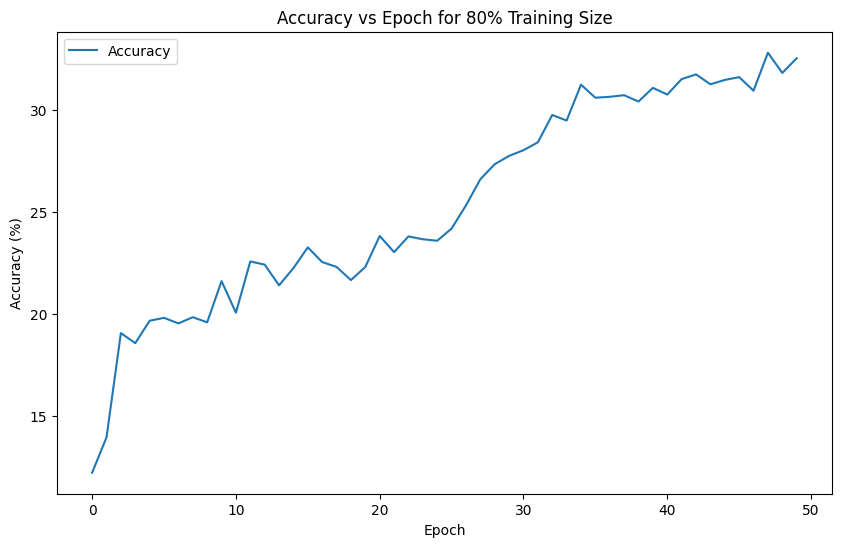

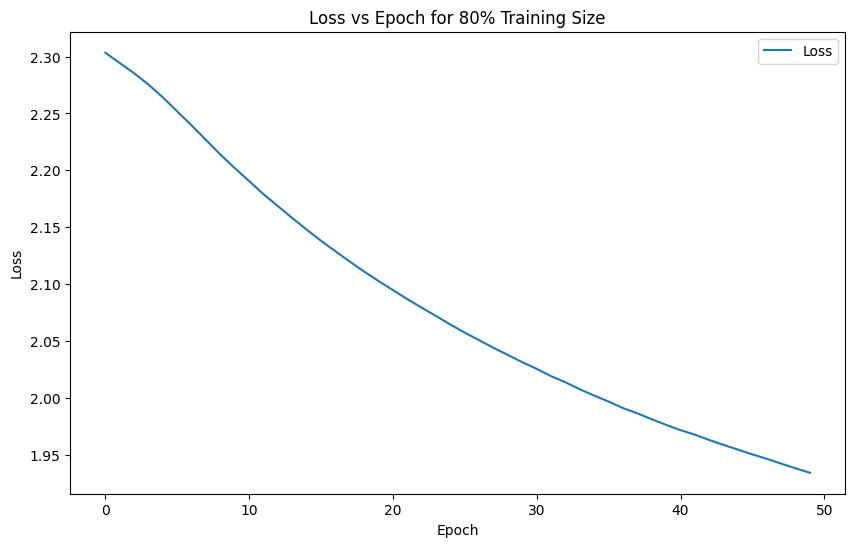

In [ ]:
# Load the training logs
logs = np.load('training_logs.npy', allow_pickle=True).item()
train_accuracies = logs['accuracy']
train_losses = logs['loss']

# Plot Accuracy vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Accuracy')
plt.title('Accuracy vs Epoch for 80% Training Size')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Plot Loss vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Loss')
plt.title('Loss vs Epoch for 80% Training Size')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
